# Véhicle counting system

**Objectif** : tester interactivement, sur une vidéo d'exemple, l'ensemble de la chaîne
avant de lancer `src/vehicle_counter.py` en conditions réelles :
- vérifier visuellement que le tracking (ByteTrack) garde des IDs stables
- vérifier que les lignes IN/OUT sont bien positionnées et que le sens compté est correct
- visualiser l'évolution des comptages dans le temps (utile pour repérer une anomalie :
  un pic anormal de comptage = souvent un ID switch du tracker, pas un vrai flux de véhicules)

Dépose une courte vidéo de test dans `data/sample_videos/` avant de lancer ce notebook.

Pas d'entraînement ici : le modèle YOLO pré-entraîné COCO connaît déjà nativement
`voiture`/`camion`/`moto`/`bus`/`velo` (voir README).

In [ ]:
import sys
sys.path.append("../src")  # pour importer counter_core.py

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO

from counter_core import LineCounter, VEHICLE_CLASSES, draw_line_with_arrow, draw_counts_table

VIDEO_PATH = "../data/sample_videos/Test_Video.mp4"  # <- adapte au nom de ta vidéo de test
assert Path(VIDEO_PATH).exists(), f"Dépose une vidéo de test dans data/sample_videos/ (attendu: {VIDEO_PATH})"


## 1.Aperçu de la 1er frame - la positionnement de lignes

Dimensions : 1280x720


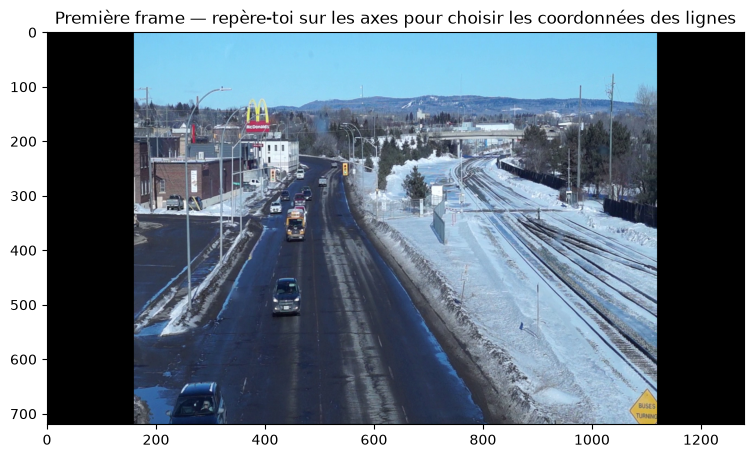

In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)
ret, first_frame = cap.read()
cap.release()
h, w = first_frame.shape[:2]
print(f"Dimensions : {w}x{h}")

plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
plt.title("Première frame — repère-toi sur les axes pour choisir les coordonnées des lignes")
plt.show()

## 2. Définition manuelle des lignes (coordonnées en pixels)

Ajuste ces valeurs en te basant sur l'image ci-dessus, puis vérifie l'aperçu
avec la flèche de sens avant de lancer le comptage complet.

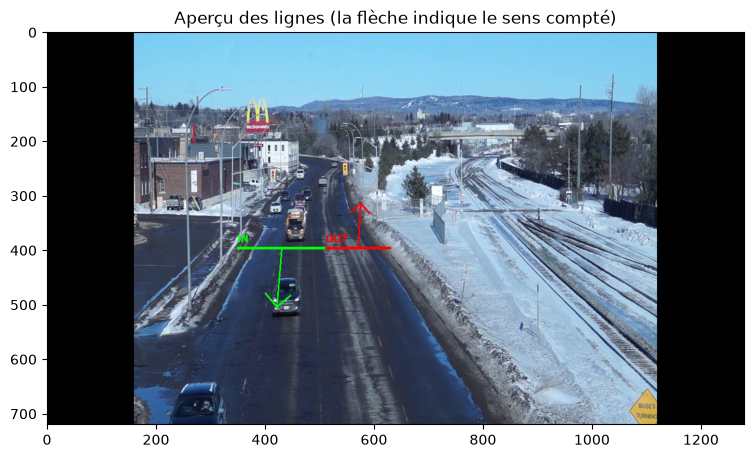

In [9]:
in_line = {"p1": (350, int(h*0.55)), "p2": (int(w*0.4), int(h*0.55)), "direction_point": (int(w*0.33), int(h*0.45)+180)}
out_line = {"p1": (int(w*0.4), int(h*0.55)), "p2": (w-650, int(h*0.55)), "direction_point": (int(w*0.45), int(h*0.45)-10)}

preview = first_frame.copy()
draw_line_with_arrow(preview, in_line, (0, 255, 0), "IN", cv2)
draw_line_with_arrow(preview, out_line, (0, 0, 255), "OUT", cv2)

plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title("Aperçu des lignes (la flèche indique le sens compté)")
plt.show()


## 3. Test du tracking sur quelques frames (contrôle visuel des IDs)

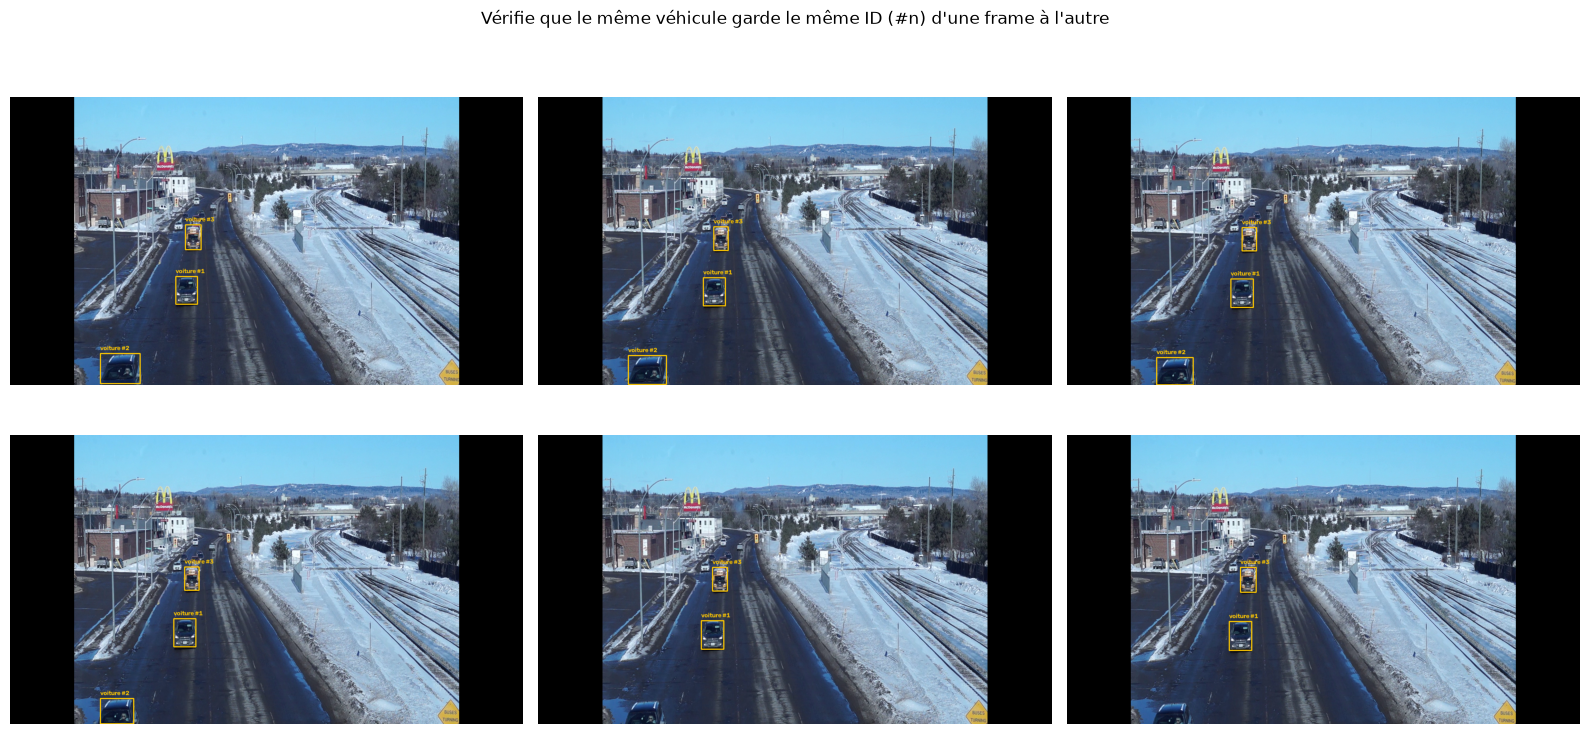

In [37]:
model = YOLO("yolov8n.pt")

stream = model.track(
    source=VIDEO_PATH, conf=0.4, classes=list(VEHICLE_CLASSES.keys()),
    tracker="bytetrack.yaml", persist=True, stream=True, verbose=False,
)

sample_frames = []
for i, result in enumerate(stream):
    if i >= 6:
        break
    frame = result.orig_img.copy()
    if result.boxes is not None and result.boxes.id is not None:
        for box, track_id, cls_id in zip(result.boxes.xyxy, result.boxes.id, result.boxes.cls):
            x1, y1, x2, y2 = map(int, box.tolist())
            cls_name = VEHICLE_CLASSES.get(int(cls_id), "autre")
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 200, 255), 2)
            cv2.putText(frame, f"{cls_name} #{int(track_id)}", (x1, y1-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 200, 255), 2)
    sample_frames.append(frame)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for frame, ax in zip(sample_frames, axes.flatten()):
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.suptitle("Vérifie que le même véhicule garde le même ID (#n) d'une frame à l'autre")
plt.tight_layout()
plt.show()


## 4. Comptage complet sur la vidéo + évolution dans le temps

In [38]:
def centroid(xyxy):
    x1, y1, x2, y2 = xyxy
    return ((x1+x2)/2, (y1+y2)/2)

counter = LineCounter(in_line, out_line)
history = []  # snapshot des totaux à chaque frame, pour tracer l'évolution

stream = model.track(
    source=VIDEO_PATH, conf=0.4, classes=list(VEHICLE_CLASSES.keys()),
    tracker="bytetrack.yaml", persist=True, stream=True, verbose=False,
)

for frame_idx, result in enumerate(stream):
    if result.boxes is not None and result.boxes.id is not None:
        for box, track_id, cls_id in zip(result.boxes.xyxy, result.boxes.id, result.boxes.cls):
            cls_name = VEHICLE_CLASSES.get(int(cls_id), "autre")
            counter.update(int(track_id), cls_name, centroid(box.tolist()))

    history.append({"frame": frame_idx, "in_total": counter.total("in"), "out_total": counter.total("out")})

hist_df = pd.DataFrame(history)
print(f"{len(hist_df)} frames traitées")
pd.DataFrame(counter.as_rows())


2531 frames traitées


,type_vehicule,nombre_entrant,nombre_sortant,vehicules_presents
0,velo,0,0,0
1,voiture,12,9,3
2,moto,0,0,0
3,bus,0,1,-1
4,camion,0,0,0
5,TOTAL,12,10,2


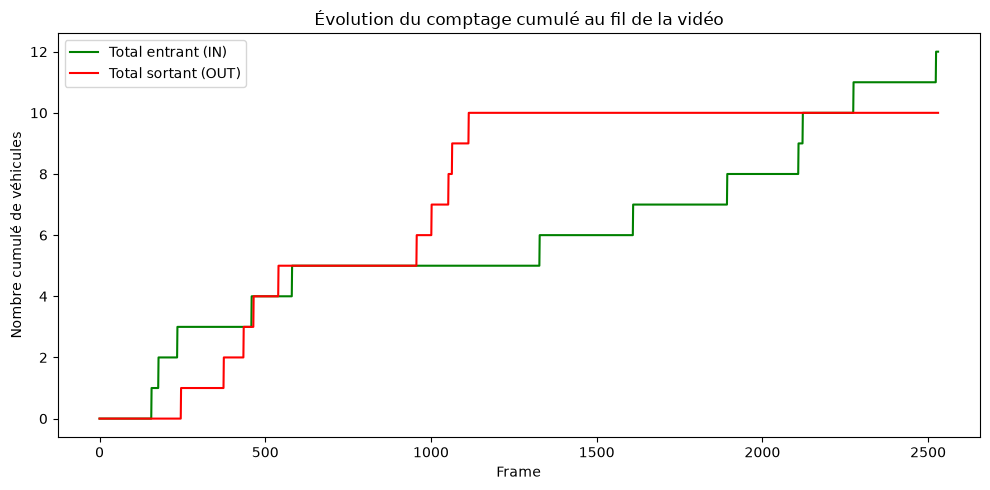

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist_df["frame"], hist_df["in_total"], label="Total entrant (IN)", color="green")
ax.plot(hist_df["frame"], hist_df["out_total"], label="Total sortant (OUT)", color="red")
ax.set_xlabel("Frame")
ax.set_ylabel("Nombre cumulé de véhicules")
ax.set_title("Évolution du comptage cumulé au fil de la vidéo")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Export des résultats du prototype

<!-- Une fois la configuration des lignes validée ici, reporte les coordonnées dans
`config/lines_config.json` (ou régénère-le avec `line_setup.py`) et lance le run
complet et reproductible :
```bash
python src/vehicle_counter.py --source data/sample_videos/example.mp4 --lines config/lines_config.json --save-video
``` -->


In [40]:
counter.export_csv("../outputs/counts_summary.csv")
counter.export_events_log("../outputs/counts_events.csv")
print("Export fait dans outputs/")


Export fait dans outputs/
